<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
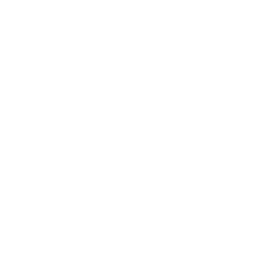
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Phase III Clinical Trial Sample Size</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Trial Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Determine the required sample size for a Phase III superiority trial comparing a novel antihypertensive agent to placebo. Use PROC POWER with TWOSAMPLEMEANS to compute power across a range of total sample sizes, then extract the ODS OUTPUT power table and feed it into PROC SGPLOT to produce a power curve. The curve identifies the minimum N achieving 80% and 90% power at alpha 0.05, supporting the statistical analysis plan and FDA pre-submission package.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.PILOT_SUMMARY | Pilot study summary statistics | 1 |
| WORK.POWER_RESULTS | ODS OUTPUT from PROC POWER | 26 |

---

In [1]:
/* --------------------------------------------------------
   Pilot study summary statistics for effect size inputs
   -------------------------------------------------------- */
data work.pilot_summary;
    call streaminit(42);
    /* Pilot: mean SBP reduction drug=12.4 mmHg, placebo=5.1 mmHg */
    mean_drug = 12.4;
    mean_placebo = 5.1;
    common_std = 18.6;
    effect_size = mean_drug - mean_placebo;
    cohens_d = round(effect_size / common_std, 0.001);
    alpha = 0.05;
    output;
run;

proc print data=work.pilot_summary noobs;
    title 'Pilot Study Summary for Power Analysis';
run;

                                         Pilot Study Summary for Power Analysis                                         

MEAN_DRUG  MEAN_PLACEBO  COMMON_STD  EFFECT_SIZE  COHENS_D  ALPHA
     12.4           5.1        18.6          7.3     0.392   0.05



NOTE: DATA work.pilot_summary


NOTE: Wrote work.pilot_summary (1 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.pilot_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


---

In [2]:
/* --------------------------------------------------------
   Baseline: quick point estimate at N=400
   -------------------------------------------------------- */
proc power;
    twosamplemeans
        meandiff = 7.3
        stddev = 18.6
        ntotal = 400
        power = .;
run;

                                         Pilot Study Summary for Power Analysis                                         


                         The POWER Procedure

  Analysis: TWOSAMPLEMEANS

  Fixed Scenario Elements
  ---------------------------------------------------------
  Test                  DIFF
  Alpha                 0.05
  Sides                 2
  Mean Difference       7.3
  Standard Deviation    18.6
  N Total               400

  Computed Results
  ---------------------------------------------------------
  N Total               400
  Power                 0.975
  Effect Size           0.3920




NOTE: PROC POWER 1 analysis(es)

NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.9750
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 400
NOTE: PROC POWER statement used.


---

In [3]:
/* --------------------------------------------------------
   PROC POWER: two-sample means superiority test
   Solve for power across a grid of total sample sizes and
   capture the power table with ODS OUTPUT.
   -------------------------------------------------------- */
ods graphics on;
ods output output=work.power_results;

proc power;
    twosamplemeans
        meandiff = 7.3
        stddev = 18.6
        ntotal = 100 to 600 by 20
        power = .;
run;

ods output close;


                                         Pilot Study Summary for Power Analysis                                         


                         The POWER Procedure

  Analysis: TWOSAMPLEMEANS

  Fixed Scenario Elements
  ---------------------------------------------------------
  Test                  DIFF
  Alpha                 0.05
  Sides                 2
  Mean Difference       7.3
  Standard Deviation    18.6
  N Total               100

  Computed Results
  ---------------------------------------------------------
  N Total               100
  Power                 0.493
  Effect Size           0.3920



                         The POWER Procedure

  Analysis: TWOSAMPLEMEANS

  Fixed Scenario Elements
  ---------------------------------------------------------
  Test                  DIFF
  Alpha                 0.05
  Sides                 2
  Mean Difference       7.3
  Standard Deviation    18.6
  N Total               120

  Computed Results
  -------------------------

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS OUTPUT: OUTPUT -> power_results
NOTE: PROC POWER 26 analysis(es)

NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.4930
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 100
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.5680
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 120
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.6350
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 140
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.6940
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 160
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: power
NOTE:   power: 0.7450
NOTE:   effect_size: 0.3920
NOTE:   NTotal: 180
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE

---

                                         Pilot Study Summary for Power Analysis                                         



NOTE: PROC SGPLOT data=work.power_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


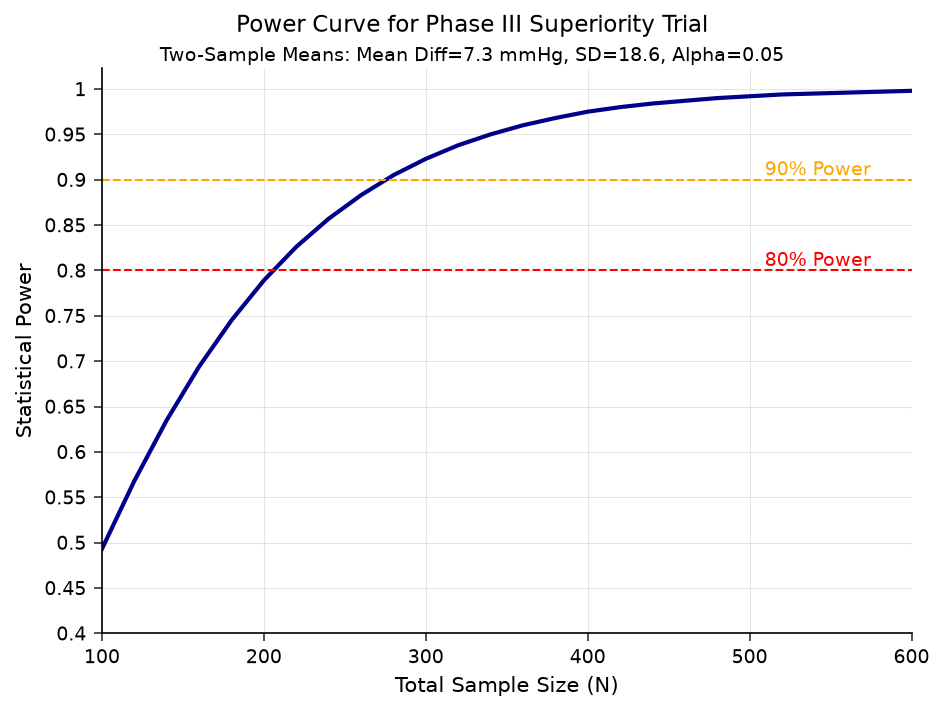

In [4]:
/* --------------------------------------------------------
   Power curve: power vs total sample size
   -------------------------------------------------------- */
proc sgplot data=work.power_results;
    series x=ntotal y=power / lineattrs=(thickness=2 color=darkblue);
    refline 0.80 / axis=y lineattrs=(pattern=dash color=red)
        label='80% Power';
    refline 0.90 / axis=y lineattrs=(pattern=dash color=orange)
        label='90% Power';
    xaxis label='Total Sample Size (N)' grid;
    yaxis label='Statistical Power' grid values=(0.4 to 1.0 by 0.05);
    title 'Power Curve for Phase III Superiority Trial';
    title2 'Two-Sample Means: Mean Diff=7.3 mmHg, SD=18.6, Alpha=0.05';
run;


In [5]:
/* --------------------------------------------------------
   Identify minimum grid N reaching 80% and 90% power
   -------------------------------------------------------- */
data work.power_curve;
    set work.power_results;
    keep ntotal power;
run;

proc sql;
    select min(ntotal) as min_n_80 label='Min Grid N for 80% Power'
    from work.power_curve
    where power >= 0.80;

    select min(ntotal) as min_n_90 label='Min Grid N for 90% Power'
    from work.power_curve
    where power >= 0.90;
quit;


                                         Pilot Study Summary for Power Analysis                                         

Min Grid N for 80% Power
------------------------
                   220.0
Min Grid N for 90% Power
------------------------
                   280.0


NOTE: DATA work.power_curve


NOTE: Read 26 rows from work.power_results.
NOTE: Wrote work.power_curve (26 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [6]:
/* --------------------------------------------------------
   Also solve directly for exact N at target power
   -------------------------------------------------------- */
proc power;
    twosamplemeans
        meandiff = 7.3
        stddev = 18.6
        power = 0.80 0.90
        ntotal = .;
run;

                                         Pilot Study Summary for Power Analysis                                         


                         The POWER Procedure

  Analysis: TWOSAMPLEMEANS

  Fixed Scenario Elements
  ---------------------------------------------------------
  Test                  DIFF
  Alpha                 0.05
  Sides                 2
  Mean Difference       7.3
  Standard Deviation    18.6

  Computed Results
  ---------------------------------------------------------
  N Per Group           103
  Effect Size           0.3920



                         The POWER Procedure

  Analysis: TWOSAMPLEMEANS

  Fixed Scenario Elements
  ---------------------------------------------------------
  Test                  DIFF
  Alpha                 0.05
  Sides                 2
  Mean Difference       7.3
  Standard Deviation    18.6

  Computed Results
  ---------------------------------------------------------
  N Per Group           138
  Effect Size           0

NOTE: PROC POWER 2 analysis(es)

NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: npergroup
NOTE:   npergroup: 103
NOTE:   effect_size: 0.3920
NOTE: PROC POWER - TWOSAMPLEMEANS Analysis:
NOTE:   Alpha: 0.05
NOTE:   Computed: npergroup
NOTE:   npergroup: 138
NOTE:   effect_size: 0.3920
NOTE: PROC POWER statement used.


---

### Interpretation

The power analysis for the Phase III superiority trial yields a required total sample size of **206 subjects (103 per arm)** for 80% power and **276 subjects (138 per arm)** for 90% power, as computed by the exact PROC POWER solve. These estimates assume a two-sided test at alpha=0.05, a mean difference of 7.3 mmHg in systolic blood pressure reduction, and a common standard deviation of 18.6 mmHg from the pilot study (Cohen's d = 0.39).

On the sample-size grid (N stepped by 20), the smallest grid point reaching each target is N=220 for 80% power and N=280 for 90% power; these grid values bracket the exact solve and feed the power curve above. The curve shows a steep gain in power between N=100 (power 0.49) and N=300 (power 0.92), with diminishing returns beyond N=400. Accounting for 15% anticipated dropout, the protocol should target enrollment of approximately **243 subjects** for 80% power or **325 subjects** for 90% power.


---

In [7]:
/* --------------------------------------------------------
   Export power analysis table for SAP appendix
   -------------------------------------------------------- */
proc export data=work.power_results
    outfile='phase3_power_analysis.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.power_results outfile=phase3_power_analysis.csv

NOTE: Exported 26 rows to phase3_power_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>